# 보완 및 진행 상황 정리

## 1. XGBClassifier 메인 모델 구축 완료

- 기존 랜덤분리 대신 시간 기준 분리를 적용함
- train: 2021.01 ~ 2023.12
- test: 2024.01 ~ 2026.02
- 과거 데이터로 학습하고 이후 시점의 사고위험을 예측하는 구조라 공모전 취지에 더 적합함

## 2. 하이퍼파라미터 튜닝 완료

- RandomizedSearchCV를 적용하여 XGBoost 하이퍼파라미터 최적값을 탐색함
- 3-fold 교차검증 기준 Best CV ROC-AUC = 0.9030

최적 모델 기준 test 성능은 다음과 같음.

- Recall = 0.8515
- ROC-AUC = 0.9008
- PR-AUC = 0.0659
- F1-score = 0.0793

## 3. Top-K Recall 분석 완료

- 위험도 상위 구간 안에 실제 사고가 얼마나 포함되는지 확인함

- Top 5% Recall = 0.3267
- Top 10% Recall = 0.6007
- Top 20% Recall = 0.8515

즉, 위험도 상위 20% 구간만 집중 관리해도 이후 실제 사고의 약 85.1%를 포함할 수 있음.  
따라서 제한된 안전관리 자원을 어디에 우선 배치할지 결정하는 정책적 근거로 활용 가능함.

## 4. Risk Score 및 위험유형 도출 완료

- XGBoost 예측확률을 0~100점 Risk Score로 변환함
- 역·호선·시간대별 위험도 순위를 생성함
- 각 구간의 주요 지수를 기준으로 위험유형을 분류함

위험유형은 다음과 같이 설정함.

- 환승형
- 구조형
- 유입형
- 혼잡형

## 5. Threshold별 성능 비교 완료

- threshold 0.3, 0.4, 0.5, 0.6, 0.7 기준 성능을 비교함
- threshold가 낮을수록 Recall은 증가하지만 FP도 함께 증가함
- threshold가 높을수록 FP는 감소하지만 실제 사고를 놓치는 FN이 증가함
- 본 연구에서는 Recall과 운영 가능성의 균형을 고려하여 threshold 0.5를 기본 기준으로 설정함

주요 결과:
- threshold 0.3: Recall 0.9571
- threshold 0.4: Recall 0.9109
- threshold 0.5: Recall 0.8515
- threshold 0.6: Recall 0.7459
- threshold 0.7: Recall 0.6436

## 6. 아직 추가하면 좋은 것

## 비교 모델 2개 돌리기

XGBClassifier만 사용하는 것보다 아래 모델들을 함께 비교하면 최종 모델 선정 근거가 더 강해짐.

- Logistic Regression
- RandomForest
- XGBClassifier

이를 통해 XGBClassifier가 가장 적합했다는 근거를 만들 수 있음.

## 선택 보완

시간이 있으면 아래 작업까지 추가하면 보고서 완성도가 더 높아짐.

- SHAP 분석
- 지도 시각화
- 최종 결과 CSV 저장

## 최종 방향

현재 XGBClassifier는 메인 모델로 가져가도 충분함.  
시간 기준 분리에서도 Recall 0.8515, ROC-AUC 0.9008로 나타났고, Top 20% Recall도 0.8515로 확인됨.  
따라서 단순 사고/비사고 분류기보다는 Risk Score 기반 위험 상위 구간 선별 모델로 활용하는 것이 적합함.

다만 최종 보고서 설득력을 높이기 위해 비교모델과 threshold 분석은 추가하는 것이 좋음.  
앙상블은 현재 단계에서는 필수 아님.

# 민영 추가
- XGBClassifier 돌릴때 하이퍼파라미터 최적값 찾는 코드 넣으면 어떨지 -> 넣었음
- 마지막 코드에서 혼잡지수가 왜 1.369633e-01 형태로 나오지?? -> 괜찮은거였음
- 로지스틱, 랜덤포레스트는 낼 우리 만나서 같이 돌려보자 -> 오키

# 기본

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 라이브러리 설치
!pip install xgboost -q

In [4]:
# 라이브러리
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

In [5]:
# csv 파일 불러오기
file_path = '/content/drive/MyDrive/서울시 빅데이터 공모전/data/processed/df_final_all_preprocessed.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig', low_memory=False)
df.head()

,사용월,호선명,time_group,혼잡,역명_clean,구조평균,구조최소,구조최대,사고수,유입,child_pop_sum,youth_pop_sum,middle_pop_sum,elder_pop_sum,환승량
0,202101,1호선,기타,85553,동대문,12.6625,10.0,19.0,0,109.158033,2.371445,28.573098,38.102411,40.111080,48535.333333
1,202101,1호선,낮시간,227205,동대문,12.6625,10.0,19.0,0,89.818268,4.140349,13.174589,27.672827,44.830502,48535.333333
2,202101,1호선,출근시간,50184,동대문,12.6625,10.0,19.0,0,57.970107,1.030731,8.346038,19.046191,29.547147,48535.333333
3,202101,1호선,퇴근시간,132625,동대문,12.6625,10.0,19.0,0,95.624161,3.856447,21.486049,28.811206,41.470459,48535.333333
4,202101,1호선,기타,34309,동묘앞,6.8375,3.0,12.0,0,70.195318,2.336531,25.357979,22.212263,20.288545,45053.333333


In [6]:
# 데이터 기본 확인
print(df.shape)
print(df.columns.tolist())
print(df.isna().sum())
df.head()

(73964, 15)
['사용월', '호선명', 'time_group', '혼잡', '역명_clean', '구조평균', '구조최소', '구조최대', '사고수', '유입', 'child_pop_sum', 'youth_pop_sum', 'middle_pop_sum', 'elder_pop_sum', '환승량']
사용월               0
호선명               0
time_group        0
혼잡                0
역명_clean          0
구조평균              0
구조최소              0
구조최대              0
사고수               0
유입                0
child_pop_sum     0
youth_pop_sum     0
middle_pop_sum    0
elder_pop_sum     0
환승량               0
dtype: int64


,사용월,호선명,time_group,혼잡,역명_clean,구조평균,구조최소,구조최대,사고수,유입,child_pop_sum,youth_pop_sum,middle_pop_sum,elder_pop_sum,환승량
0,202101,1호선,기타,85553,동대문,12.6625,10.0,19.0,0,109.158033,2.371445,28.573098,38.102411,40.111080,48535.333333
1,202101,1호선,낮시간,227205,동대문,12.6625,10.0,19.0,0,89.818268,4.140349,13.174589,27.672827,44.830502,48535.333333
2,202101,1호선,출근시간,50184,동대문,12.6625,10.0,19.0,0,57.970107,1.030731,8.346038,19.046191,29.547147,48535.333333
3,202101,1호선,퇴근시간,132625,동대문,12.6625,10.0,19.0,0,95.624161,3.856447,21.486049,28.811206,41.470459,48535.333333
4,202101,1호선,기타,34309,동묘앞,6.8375,3.0,12.0,0,70.195318,2.336531,25.357979,22.212263,20.288545,45053.333333


# 사고수 -> 사고발생 여부로 변환

In [7]:
# 사고발생 여부 타깃 변수 생성
# 사고수 > 0 이면 실제 사고가 발생한 경우이므로 1
# 사고수 = 0 이면 사고가 발생하지 않은 경우이므로 0
# 즉, 사고 "건수" 예측이 아니라 사고 "발생 여부"를 예측하는 이진분류 문제로 변환

df['사고발생'] = (df['사고수'] > 0).astype(int)

# 사고발생/미발생 데이터 개수 확인
print(df['사고발생'].value_counts())

# 사고발생/미발생 비율 확인
# 클래스 불균형 정도를 확인하기 위한 단계
print(df['사고발생'].value_counts(normalize=True))

사고발생
0    73152
1      812
Name: count, dtype: int64
사고발생
0    0.989022
1    0.010978
Name: proportion, dtype: float64


In [8]:
# 컬럼명 확인
print(df.columns.tolist())

['사용월', '호선명', 'time_group', '혼잡', '역명_clean', '구조평균', '구조최소', '구조최대', '사고수', '유입', 'child_pop_sum', 'youth_pop_sum', 'middle_pop_sum', 'elder_pop_sum', '환승량', '사고발생']


In [9]:
# 숫자형 변수 전처리
# 모델 학습에 사용할 주요 변수들을 숫자형으로 변환하는 단계
# CSV를 불러오면 숫자가 문자열로 들어오거나, 쉼표(,)가 포함되어 있을 수 있기 때문에 정리 필요

num_cols = [
    '혼잡', '유입', '구조평균', '구조최소', '구조최대',
    '환승량',
    'child_pop_sum', 'youth_pop_sum', 'middle_pop_sum', 'elder_pop_sum'
]

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)                         # 문자열로 변환
        .str.replace(',', '', regex=False)   # 숫자 안의 쉼표 제거
        .str.strip()                         # 앞뒤 공백 제거
    )

    # 숫자로 변환
    # 변환이 안 되는 값은 NaN으로 처리
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 변환 과정에서 생긴 결측치 NaN을 각 컬럼의 중앙값으로 대체
# 평균보다 중앙값이 이상치 영향을 덜 받아서 안전함
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 결측치가 남아 있는지 확인
print(df[num_cols].isna().sum())

혼잡                0
유입                0
구조평균              0
구조최소              0
구조최대              0
환승량               0
child_pop_sum     0
youth_pop_sum     0
middle_pop_sum    0
elder_pop_sum     0
dtype: int64


In [10]:
# 지수 변수 생성
# 혼잡, 유입, 구조, 환승량은 단위와 크기가 서로 다르기 때문에
# 모델이 비교하기 쉽도록 0~1 범위의 지수로 정규화하는 단계

# 혼잡 값 중 비정상적으로 큰 이상값은 NaN으로 처리
df.loc[df['혼잡'] > 10_000_000, '혼잡'] = np.nan

# 이상값 처리로 생긴 결측치는 중앙값으로 대체
df['혼잡'] = df['혼잡'].fillna(df['혼잡'].median())

# 각 변수를 최댓값으로 나누어 0~1 범위의 지수로 변환
df['혼잡지수'] = df['혼잡'] / df['혼잡'].max()
df['유입지수'] = df['유입'] / df['유입'].max()
df['구조지수'] = df['구조최대'] / df['구조최대'].max()
df['환승지수'] = df['환승량'] / df['환승량'].max()

# 역 주변 유입 인구의 전체 규모 계산
df['전체유입인구'] = (
    df['child_pop_sum'] +
    df['youth_pop_sum'] +
    df['middle_pop_sum'] +
    df['elder_pop_sum']
)

# 연령대별 취약계층 비율 변수 생성
# 고령층과 아동은 사고 위험 대응에서 중요한 정책 대상이 될 수 있음
# 1e-6은 전체유입인구가 0일 때 나누기 오류를 방지하기 위한 아주 작은 값
df['고령층비율'] = df['elder_pop_sum'] / (df['전체유입인구'] + 1e-6)
df['아동비율'] = df['child_pop_sum'] / (df['전체유입인구'] + 1e-6)

# 생성된 지수 변수들의 분포 확인
df[['혼잡지수', '유입지수', '구조지수', '환승지수', '고령층비율', '아동비율']].describe()

,혼잡지수,유입지수,구조지수,환승지수,고령층비율,아동비율
count,73964.000000,73964.000000,73964.000000,73964.000000,73964.000000,73964.000000
mean,0.072063,0.422312,0.411987,0.102789,0.253972,0.072303
std,0.069125,0.172835,0.152661,0.183503,0.089719,0.065628
min,0.000000,0.000000,0.178571,0.000000,0.000000,0.000000
25%,0.029293,0.294796,0.321429,0.000000,0.193796,0.035012
50%,0.051901,0.420421,0.382143,0.000000,0.249059,0.054296
75%,0.089952,0.538274,0.500000,0.154406,0.312207,0.084309
max,1.000000,1.000000,1.000000,1.000000,0.545968,0.479915


In [11]:
# time_group 원핫인코딩
# time_group은 '출근시간', '퇴근시간', '낮시간' 같은 문자형 범주 변수이기 때문에
# XGBoost 모델에 넣기 위해 0/1 형태의 숫자 변수로 변환

df_model = pd.get_dummies(
    df,
    columns=['time_group'],
    drop_first=False
)

# 원핫인코딩으로 생성된 시간대 컬럼만 따로 추출
time_cols = [col for col in df_model.columns if col.startswith('time_group_')]

# 모델 학습에 사용할 최종 입력 변수 목록
# 혼잡, 유입, 구조, 환승, 취약계층 비율, 시간대 정보를 사용
feature_cols = [
    '혼잡지수',
    '유입지수',
    '구조지수',
    '환승지수',
    '고령층비율',
    '아동비율'
] + time_cols

# X: 모델이 사고발생 여부를 예측할 때 사용할 설명변수
X = df_model[feature_cols]

# y: 모델이 예측해야 하는 정답값
# 사고발생 여부 0/1
y = df_model['사고발생']

# 입력 데이터 크기 확인
print(X.shape)

# 사고발생/미발생 개수 확인
print(y.value_counts())

(73964, 10)
사고발생
0    73152
1      812
Name: count, dtype: int64


# train/test 분리
- 2024년 이전 데이터 → train
- 2024년 이후 데이터 → test
# 클래스 불균형 보정

In [25]:
# 사용월 데이터 범위 확인
# 현재 데이터가 어느 기간부터 어느 기간까지 존재하는지 확인

print(df_model['사용월'].min())
print(df_model['사용월'].max())

# 월별 데이터 개수 확인
# 특정 기간에 데이터가 몰려 있거나 누락된 월이 있는지 확인하기 위한 단계
print(df_model['사용월'].value_counts().sort_index())

# 시간 기준 train/test 분리를 위해
# 2024년 이전과 이후의 사고발생 데이터 개수 확인

print("2024년 이전")
print(df_model[df_model['사용월'] < 202401]['사고발생'].value_counts())

print("2024년 이후")
print(df_model[df_model['사용월'] >= 202401]['사고발생'].value_counts())

# 해석
# train 데이터: 2021.01 ~ 2023.12
# test 데이터: 2024.01 ~ 2026.02

# 사고발생 데이터가 train/test 모두 충분히 존재하므로
# 시간 기준 분리를 적용해도 모델 학습과 성능 평가가 가능함

# 따라서 과거 데이터를 기반으로 이후 시점의 사고위험을 예측하는
# 실제 운영 환경과 유사한 방식으로 모델을 검증할 수 있음

202101
202602
사용월
202101    1176
202102    1176
202103    1188
202104    1188
202105    1188
          ... 
202510    1196
202511    1196
202512    1196
202601    1196
202602    1196
Name: count, Length: 62, dtype: int64
2024년 이전
사고발생
0    42335
1      509
Name: count, dtype: int64
2024년 이후
사고발생
0    30817
1      303
Name: count, dtype: int64


In [26]:
# 시간 기준 train/test 데이터 분리
# 목적: 과거 데이터로 학습하고 이후 데이터로 평가하여 실제 예측 상황에 가깝게 검증
# train: 2024년 1월 이전 데이터
# test: 2024년 1월 이후 데이터

train_idx = df_model['사용월'] < 202401
test_idx = df_model['사용월'] >= 202401

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]

y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

# 클래스 불균형 보정
# 사고발생 데이터가 비사고보다 훨씬 적기 때문에
# XGBoost가 사고발생 클래스를 더 중요하게 학습하도록 가중치 부여
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("train")
print(y_train.value_counts())

print("test")
print(y_test.value_counts())

print("scale_pos_weight:", scale_pos_weight)

# 시간 기준 train/test 분리 결과 해석
# train 데이터는 2024년 1월 이전 데이터로 구성됨
# 비사고 42,335개, 사고발생 509개

# test 데이터는 2024년 1월 이후 데이터로 구성됨
# 비사고 30,817개, 사고발생 303개

# train/test 모두 사고발생 데이터가 충분히 존재하므로
# 시간 기준 분리를 적용해도 모델 학습과 성능 평가가 가능함

# scale_pos_weight = 83.17
# train 데이터에서 비사고 데이터가 사고발생 데이터보다 약 83배 많다는 의미
# 따라서 XGBoost가 소수 클래스인 사고발생(1)을 더 중요하게 학습하도록
# scale_pos_weight를 적용함

# 결론
# 본 분석에서는 무작위 분할 대신 시간 기준 분할을 적용하여
# 2021.01~2023.12 데이터를 학습에 사용하고
# 2024.01~2026.02 데이터를 평가에 사용함
# 이를 통해 과거 데이터를 기반으로 이후 시점의 사고위험을 예측하는
# 실제 운영 환경과 유사한 방식으로 모델을 검증할 수 있음

train
사고발생
0    42335
1      509
Name: count, dtype: int64
test
사고발생
0    30817
1      303
Name: count, dtype: int64
scale_pos_weight: 83.17288801571709


# 민영 피드백 적용 - 하이퍼파라미터 탐색
- 하이퍼파리미터 최적값 찾는 코드

In [27]:
# XGBoost 하이퍼파라미터 튜닝
# 목적: 여러 파라미터 조합 중 교차검증 ROC-AUC가 가장 높은 조합을 찾기

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# 튜닝 전 기본 XGBoost 모델 생성
# scale_pos_weight는 사고발생 데이터가 적은 클래스 불균형 문제를 보정하기 위해 사용
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

# 탐색할 하이퍼파라미터 후보 목록
# RandomizedSearchCV가 아래 후보들 중 일부 조합을 랜덤으로 선택하여 성능을 비교
param_dist = {
    'n_estimators': [100, 200, 300, 500],        # 생성할 트리 개수
    'max_depth': [2, 3, 4, 5],                   # 각 트리의 최대 깊이
    'learning_rate': [0.01, 0.03, 0.05, 0.1],    # 학습률
    'subsample': [0.7, 0.8, 0.9, 1.0],           # 각 트리 학습에 사용할 데이터 비율
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],    # 각 트리 학습에 사용할 변수 비율
    'min_child_weight': [1, 3, 5],               # 리프 노드 분할을 위한 최소 가중치
    'reg_alpha': [0, 0.1, 0.5],                  # L1 정규화
    'reg_lambda': [1, 3, 5]                      # L2 정규화
}

# RandomizedSearchCV 실행
# n_iter=30 → 전체 후보 조합 중 30개 조합만 랜덤으로 탐색
# cv=3 → 3-fold 교차검증
# scoring='roc_auc' → 사고/비사고 구분 성능을 기준으로 최적 조합 선택
search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# train 데이터에서 하이퍼파라미터 탐색 수행
search.fit(X_train, y_train)

# 가장 성능이 좋았던 하이퍼파라미터 조합 확인
print("Best Parameters:")
print(search.best_params_)

# 가장 좋은 조합의 교차검증 ROC-AUC 점수 확인
print("Best CV Score:")
print(search.best_score_)

# 최적 하이퍼파라미터가 적용된 모델을 최종 XGBoost 모델로 사용
xgb_clf = search.best_estimator_

# 하이퍼파라미터 튜닝 결과 해석
# RandomizedSearchCV를 통해 총 30개의 XGBoost 파라미터 조합을 탐색했고,
# 각 조합은 3-fold 교차검증으로 평가되었기 때문에 총 90번의 학습이 수행됨.

# 최적 파라미터 조합:
# subsample=0.8 → 각 트리 학습 시 train 데이터의 80%만 사용
# colsample_bytree=0.7 → 각 트리 학습 시 전체 변수의 70%만 사용
# n_estimators=300 → 총 300개의 트리 생성
# max_depth=5 → 각 트리의 최대 깊이를 5로 설정
# learning_rate=0.01 → 낮은 학습률로 천천히 학습하여 과적합을 줄임
# min_child_weight=5 → 리프 노드 분할 조건을 비교적 보수적으로 설정
# reg_alpha=0.5 → L1 정규화를 적용하여 불필요한 변수 영향 감소
# reg_lambda=3 → L2 정규화를 적용하여 과적합 방지

# Best CV Score = 0.9030
# 시간 기준으로 분리한 train 데이터에서 교차검증 ROC-AUC가 약 0.903으로 나타남
# 즉, 튜닝된 XGBoost 모델은 과거 데이터 내부 검증에서도
# 사고발생/미발생을 구분하는 능력이 전반적으로 우수함

# 결론
# 시간 기준 분리를 적용한 이후에도 XGBoost 모델의 교차검증 성능이 안정적으로 나타남
# 따라서 과거 데이터를 기반으로 이후 시점의 사고위험을 예측하는 모델로 활용 가능함

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV Score:
0.9030269203506739


In [28]:
# 최적 하이퍼파라미터가 적용된 XGBoost 모델을 최종 모델로 사용
xgb_clf = search.best_estimator_

# XGBoost Classifier 학습
```
# XGBoost 학습 구조 정리
# 현재 모델은 XGBClassifier를 직접 한 번만 학습하는 방식이 아니라,
# RandomizedSearchCV를 사용해 여러 하이퍼파라미터 조합을 비교한 뒤
# 가장 성능이 좋은 XGBClassifier를 최종 모델로 선택하는 방식임

# 1. xgb_base = XGBClassifier(...)
#    → 튜닝의 기준이 되는 기본 XGBoost 분류 모델 생성

# 2. search = RandomizedSearchCV(estimator=xgb_base, ...)
#    → XGBClassifier의 여러 하이퍼파라미터 조합을 탐색하도록 설정

# 3. search.fit(X_train, y_train)
#    → train 데이터로 여러 XGBClassifier 조합을 학습하고,
#      교차검증 ROC-AUC가 가장 높은 조합을 선택

# 4. xgb_clf = search.best_estimator_
#    → 가장 성능이 좋았던 XGBClassifier를 최종 모델로 저장

# 따라서 최종 모델은 XGBClassifier가 맞으며,
# 단순 XGBClassifier가 아니라 하이퍼파라미터 튜닝을 거친 XGBClassifier임
```

In [29]:
# XGBoost Classifier 학습
# 사고발생 여부(0/1)를 예측하는 메인 모델
# scale_pos_weight를 넣어서 사고발생 데이터가 적은 문제를 보정
# -> 이거 이제 사용 X
'''
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=3,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train, y_train)
'''

"\nfrom xgboost import XGBClassifier\n\nxgb_clf = XGBClassifier(\n    n_estimators=300,\n    max_depth=3,\n    learning_rate=0.03,\n    subsample=0.8,\n    colsample_bytree=0.8,\n    min_child_weight=3,\n    reg_alpha=0.1,\n    reg_lambda=3,\n    objective='binary:logistic',\n    eval_metric='logloss',\n    scale_pos_weight=scale_pos_weight,\n    random_state=42,\n    n_jobs=-1\n)\n\nxgb_clf.fit(X_train, y_train)\n"

# 성능 평가

In [30]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train")
print(y_train.value_counts())

print("y_test")
print(y_test.value_counts())

X_train: (42844, 10)
X_test: (31120, 10)
y_train
사고발생
0    42335
1      509
Name: count, dtype: int64
y_test
사고발생
0    30817
1      303
Name: count, dtype: int64


In [47]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    recall_score,
    f1_score
)

# test 데이터에 대해 사고발생 확률 예측
y_proba = xgb_clf.predict_proba(X_test)[:, 1]

# 최종 운영 threshold 설정
# Threshold 분석 결과를 바탕으로 0.5 사용
THRESHOLD = 0.5

# threshold 기준 사고발생 여부 예측
y_pred = (y_proba >= THRESHOLD).astype(int)

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred, digits=4))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

# 시간 기준 test 성능 해석
# Recall = 0.8515
# 2024년 이후 실제 사고 303건 중 258건을 탐지함
# 즉, 이후 시점 사고발생 사례의 약 85.1%를 잡아냄

# ROC-AUC = 0.9008
# 과거 데이터로 학습한 모델이 이후 데이터에서도 사고/비사고를 구분하는 능력이 우수함

# Precision = 0.0416
# 사고위험으로 예측한 구간 중 실제 사고 비율은 낮음
# 이는 사고발생 데이터가 전체 test 데이터의 약 1% 수준으로 매우 적은 불균형 데이터이기 때문

# Confusion Matrix 해석
# 실제 사고 303건 중 258건을 맞히고 45건을 놓침
# 실제 비사고 30,817건 중 5,944건을 사고위험으로 예측함

# 결론
# 시간 기준 분리를 적용했을 때도 Recall 0.8515, ROC-AUC 0.9008로 나타남
# 따라서 본 모델은 과거 데이터를 기반으로 이후 시점의 사고위험을 예측하는 데 활용 가능함
# 다만 Precision이 낮기 때문에 단순 사고/비사고 분류기보다는
# Risk Score 기반 위험 상위 구간 선별 모델로 활용하는 것이 적합함

Confusion Matrix
[[24873  5944]
 [   45   258]]

Classification Report
              precision    recall  f1-score   support

           0     0.9982    0.8071    0.8925     30817
           1     0.0416    0.8515    0.0793       303

    accuracy                         0.8076     31120
   macro avg     0.5199    0.8293    0.4859     31120
weighted avg     0.9889    0.8076    0.8846     31120

ROC-AUC: 0.9008303140727156
PR-AUC: 0.06590955049677279
Recall: 0.8514851485148515
F1-score: 0.07932359723289777


In [48]:
# threshold=0.5는 Threshold별 성능 비교에서
# Recall과 운영 가능성의 균형이 가장 적절하다고 판단한 기준값임

# 최종 운영 threshold 설정
# Threshold 분석 결과를 바탕으로 0.5 사용
# threshold=0.5는 Threshold별 성능 비교에서
# Recall과 운영 가능성의 균형이 가장 적절하다고 판단한 기준값임
THRESHOLD = 0.5

In [ ]:
# 시간 기준 분리 후 튜닝된 XGBoost 성능 해석
# Recall = 0.8515
# 2024년 이후 실제 사고 발생 303개 중 258개를 탐지함
# 즉, 이후 시점 사고 발생 사례의 약 85.1%를 잡아냈다는 의미

# ROC-AUC = 0.9008
# 과거 데이터로 학습한 모델이 이후 데이터에서도
# 사고발생/미발생을 구분하는 전체적인 능력이 우수함

# Precision = 0.0416
# 사고위험으로 예측한 구간 중 실제 사고 발생 비율은 낮음
# 이는 사고 데이터가 전체 test 데이터의 약 1% 수준으로 매우 적은
# 클래스 불균형 데이터이기 때문

# F1-score = 0.0793
# Precision이 낮아 F1-score는 높지 않지만,
# 본 분석의 목적은 단순 분류 정확도보다 사고 위험 구간을 놓치지 않고 선별하는 데 있음

# Confusion Matrix 해석
# 실제 사고 303개 중 258개를 맞히고 45개를 놓침
# 실제 비사고 30,817개 중 5,944개를 사고위험으로 예측함

# 결론
# 시간 기준 분리를 적용한 결과, Recall 0.8515와 ROC-AUC 0.9008을 기록함
# 이는 과거 데이터로 학습한 모델이 이후 시점의 사고 위험도도 일정 수준 이상 예측할 수 있음을 의미함
# 다만 Precision이 낮기 때문에 단순 사고/비사고 분류기보다는
# 예측확률을 활용한 Risk Score 기반 위험 상위 구간 선별 모델로 활용하는 것이 적합함

# Threshold별 성능 비교

In [45]:
# Threshold별 성능 비교
# 목적: 사고위험 판단 기준을 0.3~0.7로 바꿨을 때
# Recall, Precision, F1이 어떻게 달라지는지 확인

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = []

for th in thresholds:
    # threshold 이상이면 사고발생 1로 예측
    y_pred_th = (y_proba >= th).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_th).ravel()

    threshold_results.append({
        'threshold': th,
        'precision': precision_score(y_test, y_pred_th, zero_division=0),
        'recall': recall_score(y_test, y_pred_th),
        'f1_score': f1_score(y_test, y_pred_th),
        'TP_실제사고탐지': tp,
        'FN_놓친사고': fn,
        'FP_위험으로예측했지만비사고': fp,
        'TN_비사고정답': tn
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

# Threshold별 성능 비교 결과 해석
# threshold는 모델이 예측한 사고발생 확률을 실제 사고위험 여부로 바꾸는 기준값임
# 예를 들어 threshold=0.5이면 사고발생 확률이 0.5 이상인 구간을 사고위험으로 판단함

# threshold를 낮출수록 더 많은 구간을 사고위험으로 예측함
# 따라서 실제 사고를 놓치는 경우(FN)는 줄어들고 Recall은 높아짐
# threshold=0.3에서는 실제 사고 303건 중 290건을 탐지하여 Recall이 0.9571로 가장 높게 나타남
# 하지만 비사고 구간을 사고위험으로 잘못 예측한 경우(FP)도 8,350건으로 가장 많음

# threshold를 높일수록 사고위험 판단 기준이 엄격해짐
# 따라서 비사고 구간을 위험으로 잘못 판단하는 FP는 줄어듦
# threshold=0.7에서는 FP가 3,405건으로 감소함
# 하지만 실제 사고를 놓친 경우(FN)가 108건으로 증가하고 Recall은 0.6436까지 낮아짐

# 본 분석의 목적은 사고위험 구간을 사전에 선별하여 안전관리 우선순위를 정하는 것임
# 따라서 단순히 Precision을 높이는 것보다 실제 사고를 최대한 놓치지 않는 Recall이 더 중요함

# threshold=0.5에서는 실제 사고 303건 중 258건을 탐지하여 Recall 0.8515를 기록함
# 동시에 threshold=0.3, 0.4보다 과도한 위험구간 지정도 줄일 수 있음
# 따라서 threshold=0.5는 사고 탐지율과 운영 가능성 사이의 균형점으로 볼 수 있음

# 결론
# 본 모델은 기본 threshold 0.5 기준에서 실제 사고의 약 85.1%를 탐지함
# 이는 제한된 안전관리 자원을 위험 가능성이 높은 역·시간대에 우선 배치하는 데 활용 가능함
# 다만 정책적으로 더 보수적인 안전관리가 필요할 경우 threshold를 0.3 또는 0.4로 낮춰
# 사고 누락을 최소화하는 방식으로 운영할 수 있음

,threshold,precision,recall,f1_score,TP_실제사고탐지,FN_놓친사고,FP_위험으로예측했지만비사고,TN_비사고정답
0,0.3,0.033565,0.957096,0.064855,290,13,8350,22467
1,0.4,0.037202,0.910891,0.071484,276,27,7143,23674
2,0.5,0.041599,0.851485,0.079324,258,45,5944,24873
3,0.6,0.044841,0.745875,0.084597,226,77,4814,26003
4,0.7,0.054167,0.643564,0.099923,195,108,3405,27412


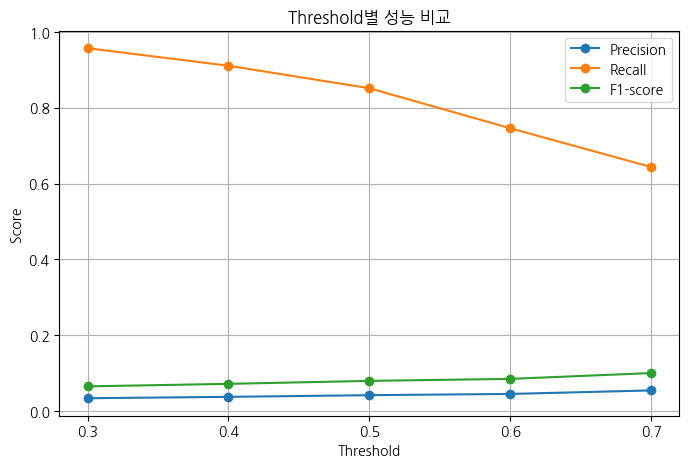

In [46]:
# Threshold별 Precision / Recall / F1 시각화
# threshold를 낮추면 Recall은 보통 올라가고,
# threshold를 높이면 Precision은 보통 올라감

plt.figure(figsize=(8, 5))

plt.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['f1_score'], marker='o', label='F1-score')

plt.title('Threshold별 성능 비교')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.xticks(thresholds)
plt.legend()
plt.grid(True)
plt.show()

# 그래프 해석
# threshold가 낮을수록 더 많은 구간을 사고위험으로 판단함
# 따라서 실제 사고를 놓치는 경우가 줄어들어 Recall은 높아짐
# threshold=0.3에서는 Recall이 0.9571로 가장 높게 나타남

# 하지만 threshold를 너무 낮추면
# 실제로는 사고가 없는 구간도 위험구간으로 많이 예측하게 됨
# 따라서 Precision은 낮아지는 경향을 보임

# 반대로 threshold를 높이면 사고위험 판단 기준이 엄격해짐
# 따라서 위험구간으로 지정되는 범위는 줄어들고
# Precision과 F1-score는 점진적으로 증가함

# 하지만 threshold가 높아질수록 실제 사고를 놓치는 경우(FN)가 증가하여
# Recall은 감소하는 경향을 보임
# threshold=0.7에서는 Recall이 0.6436까지 감소함

# 즉, threshold 설정에 따라
# "실제 사고를 최대한 많이 탐지할 것인지"
# 또는
# "과도한 위험구간 지정을 줄일 것인지"
# 사이의 trade-off가 발생함

# 본 연구의 목적은 사고위험 구간을 사전에 선별하여
# 안전관리 우선순위를 정하는 것이므로
# Precision보다 Recall을 더 중요하게 고려함

# threshold=0.5에서는 Recall 0.8515를 기록하여
# 실제 사고의 약 85.1%를 탐지할 수 있었음
# 동시에 threshold=0.3, 0.4보다 과도한 위험구간 지정도 줄일 수 있었음

# 따라서 threshold=0.5는
# 사고 탐지율과 운영 가능성 사이의 균형점으로 적절하다고 판단함

In [ ]:
# Threshold별 결과 요약
# threshold=0.3
# Recall 0.9571로 실제 사고 대부분을 탐지함
# 하지만 FP(비사고를 위험으로 예측한 경우)가 매우 많아
# 과도한 위험구간 지정 문제가 발생할 수 있음

# threshold=0.4
# Recall 0.9109로 여전히 높은 사고 탐지율을 보임
# 하지만 FP가 여전히 많아 운영 부담 가능성이 존재함

# threshold=0.5
# Recall 0.8515로 실제 사고의 약 85.1%를 탐지함
# 동시에 threshold 0.3, 0.4보다 FP를 줄일 수 있어
# 사고 탐지율과 운영 가능성 사이의 균형이 가장 적절한 구간으로 판단됨

# threshold=0.6
# FP는 감소하지만 실제 사고를 놓치는 경우(FN)가 증가하기 시작함
# Recall도 0.7459까지 감소함

# threshold=0.7
# 위험구간 지정은 줄어들지만
# Recall이 0.6436까지 감소하여 실제 사고를 많이 놓치게 됨

# 결론
# 본 연구는 사고위험 구간을 사전에 선별하는 것이 목적이므로
# Precision보다 Recall을 더 중요하게 고려함
# 따라서 실제 사고의 약 85.1%를 탐지하면서
# 운영 가능성도 고려할 수 있는 threshold=0.5를
# 기본 운영 기준으로 설정함

# Top-K Recall 확인
## 여기까지 정리

```
Recall = 0.8515
ROC-AUC = 0.9008
Top 5% Recall = 0.3267
Top 10% Recall = 0.6007
Top 20% Recall = 0.8515
```

- 시간 기준 분리 결과, 과거 데이터로 학습한 모델이 이후 사고위험도 일정 수준 이상 예측함
- 특히 Top 10% 위험구간 안에 실제 사고의 약 60.1%가 포함됨
- Top 20% 위험구간까지 확대하면 실제 사고의 약 85.1%를 포함함
- 따라서 본 모델은 단순 사고/비사고 분류보다 위험 상위 구간을 선별하는 정책 우선순위 모델로 활용하기 적합함

---

## 지금 상태 평가
- 모델 구조: 좋음
- 검증 방식: 좋음, 시간 기준 분리 적용
- 성능: 좋음, Recall 0.8515 / ROC-AUC 0.9008
- 정책 활용성: 좋음, Top-K Recall 기반 위험구간 우선관리 가능
- 해석 가능성: 좋음, 변수 중요도와 위험유형 확보
- 공모전용 적합도: 매우 적합

In [33]:
# Top-K Recall 계산
# 목적: 모델이 위험하다고 예측한 상위 구간 안에
# 실제 사고발생 사례가 얼마나 포함되는지 확인
# 공모전에서는 전체 구간을 모두 관리하는 것보다
# 위험 상위 구간을 우선 관리하는 전략이 중요하므로 Top-K Recall을 확인함

test_result = X_test.copy()

# 실제 사고발생 여부
test_result['actual'] = y_test.values

# XGBoost가 예측한 사고발생 확률
# 이 값을 Risk Score의 기준으로 사용
test_result['risk_proba'] = y_proba

# 위험도 상위 5%, 10%, 20% 구간별 실제 사고 포함률 계산
for ratio in [0.05, 0.10, 0.20]:
    top_n = int(len(test_result) * ratio)

    # 예측 위험확률이 높은 순서대로 정렬 후 상위 ratio만 선택
    top_risk = (
        test_result
        .sort_values('risk_proba', ascending=False)
        .head(top_n)
    )

    # Top-K Recall = 상위 위험구간 안 실제 사고 수 / 전체 실제 사고 수
    top_recall = top_risk['actual'].sum() / test_result['actual'].sum()

    print(f"Top {int(ratio * 100)}% Recall:", top_recall)
    print(f"Top {int(ratio * 100)}% 안 실제 사고발생 수:", top_risk['actual'].sum())
    print("전체 실제 사고발생 수:", test_result['actual'].sum())
    print("-" * 40)

# Top-K Recall 결과 해석
# Top 5% Recall = 0.3267
# 위험도 상위 5% 구간에는 전체 실제 사고 303건 중 99건이 포함됨
# 즉, 전체 구간의 5%만 우선 관리하더라도 실제 사고의 약 32.7%를 포착할 수 있음

# Top 10% Recall = 0.6007
# 위험도 상위 10% 구간에는 전체 실제 사고 303건 중 182건이 포함됨
# 즉, 상위 10% 위험구간 관리만으로 실제 사고의 약 60.1%를 포착할 수 있음

# Top 20% Recall = 0.8515
# 위험도 상위 20% 구간에는 전체 실제 사고 303건 중 258건이 포함됨
# 즉, 상위 20% 위험구간을 집중 관리하면 실제 사고의 약 85.1%를 포함할 수 있음

# 결론
# 시간 기준 분리 이후에도 XGBoost 기반 Risk Score는
# 실제 사고발생 구간을 위험도 상위 구간에 효과적으로 집중시키는 것으로 나타남
# 따라서 본 모델은 단순 사고/비사고 분류보다
# 제한된 안전관리 자원을 어디에 우선 배치할지 결정하는
# 위험구간 우선순위 선정 모델로 활용하기에 적합함

Top 5% Recall: 0.32673267326732675
Top 5% 안 실제 사고발생 수: 99
전체 실제 사고발생 수: 303
----------------------------------------
Top 10% Recall: 0.6006600660066007
Top 10% 안 실제 사고발생 수: 182
전체 실제 사고발생 수: 303
----------------------------------------
Top 20% Recall: 0.8514851485148515
Top 20% 안 실제 사고발생 수: 258
전체 실제 사고발생 수: 303
----------------------------------------


# 변수 중요도 확인
-> 왜 위험하다고 판단했는지 설명

In [34]:
# 변수 중요도 확인
# XGBoost가 사고발생 예측에서 어떤 변수를 중요하게 사용했는지 확인

importance = pd.Series(
    xgb_clf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

# 변수 중요도 출력
print(importance)

# 변수 중요도 결과 해석
# XGBoost 모델이 사고발생 예측에서 가장 중요하게 사용한 변수는 환승지수로 나타남
# 환승지수 중요도 = 0.4385
# 즉, 환승량이 많고 동선이 복잡한 역·시간대가 사고위험 예측에 가장 큰 설명력을 가짐

# 주요 변수 순위
# 1위 환승지수: 0.4385
# 2위 유입지수: 0.0866
# 3위 time_group_출근시간: 0.0830
# 4위 time_group_기타: 0.0797
# 5위 구조지수: 0.0685

# 해석
# 사고위험은 환승 관련 요인의 영향이 가장 크게 나타났으며,
# 유입 규모와 시간대 변수도 주요 변수로 확인됨

# 특히 출근시간 변수의 중요도가 높게 나타난 것은
# 출근시간대의 집중 혼잡과 승객 흐름이 사고위험 형성에 영향을 줄 가능성을 시사함

# 구조지수와 혼잡지수 역시 주요 변수로 나타나,
# 사고위험이 단순 혼잡도 하나로만 결정되는 것이 아니라
# 환승, 유입, 구조, 시간대 요인이 복합적으로 작용한 결과임을 보여줌

# 고령층비율과 아동비율도 일정 수준의 중요도를 보임
# 이는 취약계층 특성을 고려한 맞춤형 안전 대책 필요성을 시사함

# 주의
# 변수 중요도는 인과관계를 의미하지 않음
# 따라서 "환승이 사고의 원인이다"가 아니라
# "환승 관련 변수가 사고발생 예측에 높은 설명력을 보였다"라고 해석해야 함

환승지수               0.438472
유입지수               0.086636
time_group_출근시간    0.083044
time_group_기타      0.079666
구조지수               0.068451
혼잡지수               0.062897
고령층비율              0.052099
아동비율               0.051982
time_group_퇴근시간    0.049034
time_group_낮시간     0.027720
dtype: float32


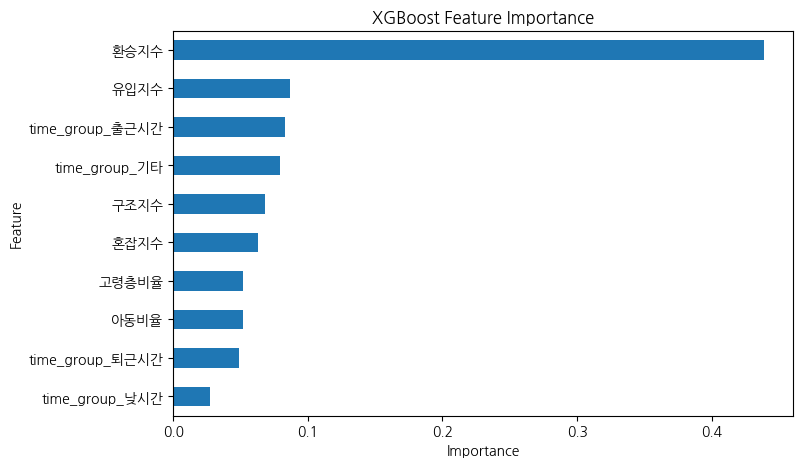

In [35]:
# 변수 중요도 시각화
# XGBoost 모델이 사고발생 예측에 어떤 변수를 중요하게 사용했는지 그래프로 확인

# Colab 한글 폰트 설치
!apt-get -qq install fonts-nanum

# matplotlib 한글 폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rc('font', family='NanumGothic')
mpl.rcParams['axes.unicode_minus'] = False

# 변수 중요도 막대그래프
plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# 해석
# 환승지수가 가장 높은 중요도를 보임
# 이는 환승량과 환승 동선의 복잡성이 사고발생 예측에 높은 설명력을 가진다는 의미

# 유입지수와 출근시간 변수도 높은 중요도를 보임
# 이는 특정 시간대 집중 유입과 승객 흐름이 사고위험 형성에 영향을 줄 가능성을 시사함

# 구조지수와 혼잡지수 역시 주요 변수로 나타나
# 사고위험이 단일 요인보다
# 환승, 유입, 구조, 혼잡, 시간대 요인이 복합적으로 작용한 결과임을 보여줌

# 고령층비율과 아동비율도 일정 수준의 중요도를 보여
# 취약계층 특성을 고려한 맞춤형 안전 대책 필요성을 뒷받침함

# 단, 변수 중요도는 인과관계를 의미하지 않으므로
# "환승이 사고의 직접 원인이다"가 아니라
# "환승 관련 변수가 사고위험 예측에 크게 활용되었다"라고 해석해야 함

# SHAP
## SHAP 분석이란?

SHAP은 모델이 어떤 이유로 특정 예측을 했는지 설명하기 위한 Explainable AI 기법이다.

일반적인 머신러닝 모델은 예측 결과는 보여주지만, 왜 그런 결과가 나왔는지는 직관적으로 알기 어렵다.  
SHAP은 각 입력 변수가 예측값을 높이는 방향으로 작용했는지, 낮추는 방향으로 작용했는지를 수치와 그래프로 보여준다.

예를 들어 지하철 사고위험 예측 모델에서 특정 역·시간대의 Risk Score가 높게 나왔다면, SHAP을 통해 다음과 같은 해석이 가능하다.

- 환승지수가 위험도를 얼마나 높였는지
- 혼잡지수가 위험도에 얼마나 영향을 줬는지
- 구조지수나 유입지수가 예측에 어떤 방향으로 작용했는지
- 특정 시간대 변수가 사고위험 판단에 영향을 줬는지

즉, SHAP은 단순히 “위험하다”라고 예측하는 것을 넘어서,  
“왜 위험하다고 판단했는지”를 설명해주는 분석 방법이다.

본 연구에서는 SHAP 분석을 활용하여 XGBoost 모델의 사고위험 예측 결과를 해석하고,  
위험도 산정 결과를 정책적으로 설명 가능한 형태로 제시하고자 한다.

In [49]:
# SHAP 설치
!pip install shap -q

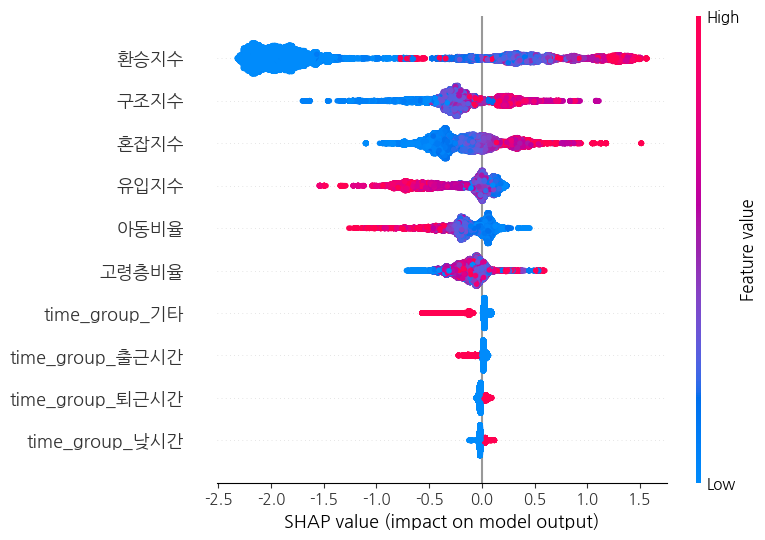

In [50]:
# SHAP 분석
# 목적: XGBoost 모델이 사고위험을 예측할 때
# 어떤 변수가 예측값을 높이거나 낮췄는지 확인

import shap

# TreeExplainer는 XGBoost, RandomForest 같은 트리 기반 모델 해석에 적합함
explainer = shap.TreeExplainer(xgb_clf)

# test 데이터 기준으로 SHAP 값 계산
# shap_values는 각 행/각 변수별로 예측에 기여한 정도를 의미함
shap_values = explainer.shap_values(X_test)

# SHAP summary plot
# 각 변수가 사고위험 예측에 미친 영향의 크기와 방향을 함께 보여줌
# 점 하나 = test 데이터의 한 행
# 빨간색 = 해당 변수값이 높음
# 파란색 = 해당 변수값이 낮음
# 오른쪽 = 사고위험 예측값을 높이는 방향
# 왼쪽 = 사고위험 예측값을 낮추는 방향
shap.summary_plot(shap_values, X_test)

# SHAP summary plot 결과 해석
# SHAP 분석 결과, 사고위험 예측에 가장 큰 영향을 준 변수는 환승지수로 나타남
# 환승지수는 그래프의 가장 위에 위치하고, SHAP value의 퍼짐도 가장 크게 나타남
# 이는 모델이 사고위험을 판단할 때 환승 관련 요인을 가장 중요하게 활용했다는 의미임

# 환승지수에서 빨간 점은 오른쪽에 많이 분포함
# 빨간 점은 해당 변수값이 높은 경우를 의미하고,
# 오른쪽은 사고위험 예측값을 높이는 방향을 의미함
# 따라서 환승지수가 높을수록 사고위험 예측값이 증가하는 경향이 있다고 해석할 수 있음

# 구조지수와 혼잡지수도 상위 변수로 나타남
# 두 변수 역시 값이 높을수록 SHAP value가 양의 방향으로 이동하는 경향을 보여
# 구조적 위험이나 혼잡 수준이 높을수록 사고위험 예측에 영향을 주는 것으로 볼 수 있음

# 유입지수는 높은 값이 왼쪽과 오른쪽에 함께 분포함
# 따라서 유입지수는 단순히 값이 높을수록 위험도가 증가한다고 단정하기보다는
# 환승, 혼잡, 구조 요인과 함께 복합적으로 작용하는 변수로 해석하는 것이 적절함

# 시간대 변수(time_group)는 상대적으로 아래쪽에 위치하고 SHAP value의 변화 폭도 작음
# 이는 시간대 자체보다 환승지수, 구조지수, 혼잡지수 같은 공간적·구조적 요인이
# 사고위험 예측에 더 큰 설명력을 가진다는 것을 의미함

# 결론
# SHAP 분석을 통해 XGBoost 모델이 단순히 사고위험을 예측하는 데 그치지 않고,
# 환승, 구조, 혼잡 등 실제 안전관리와 연결 가능한 요인을 근거로
# 위험도를 산정하고 있음을 확인함
# 따라서 본 모델은 Explainable AI 기반 사고위험 해석 모델로 활용 가능함

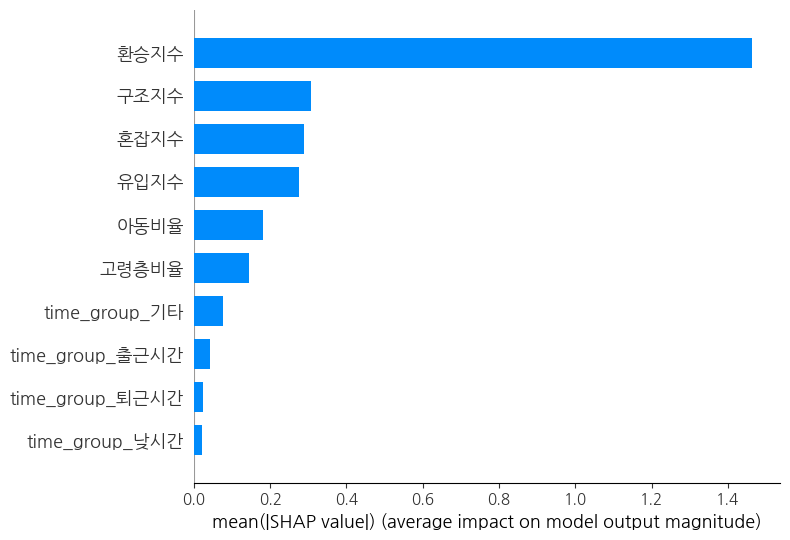

In [51]:
# SHAP 변수 중요도 막대그래프
# 목적: 각 변수가 전체 test 데이터에서 평균적으로 얼마나 큰 영향을 줬는지 확인
# summary plot은 영향 방향까지 보여주고,
# bar plot은 변수 중요도 순위를 더 깔끔하게 보여줌

shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

# SHAP 변수 중요도 막대그래프 결과 해석
# SHAP bar plot은 각 변수의 SHAP 절댓값 평균(mean(|SHAP value|))을 기준으로
# 모델 예측에 평균적으로 얼마나 큰 영향을 주었는지 보여줌

# 값이 클수록 해당 변수가 사고위험 예측에 더 큰 영향을 준다는 의미임

# 분석 결과 환승지수가 가장 높은 중요도를 보였음
# 이는 XGBoost 모델이 사고위험을 예측할 때
# 환승 관련 요인을 가장 중요하게 활용하고 있음을 의미함

# 특히 환승지수의 중요도가 다른 변수보다 매우 크게 나타나
# 환승량과 환승 동선 복잡성이 사고위험 형성에 핵심적인 역할을 할 가능성을 시사함

# 구조지수와 혼잡지수도 높은 중요도를 보였음
# 이는 승강장 구조 특성과 혼잡 수준이 사고위험 예측에 주요하게 작용했음을 의미함

# 유입지수 역시 일정 수준 이상의 중요도를 보였으며,
# 역 주변 유입 인구 규모도 사고위험 형성에 영향을 줄 가능성이 있음을 보여줌

# 아동비율과 고령층비율은 상대적으로 영향력이 작지만,
# 취약계층 특성을 반영하는 변수로 일정 수준의 설명력을 보였음

# 시간대 변수(time_group)는 상대적으로 중요도가 낮게 나타남
# 이는 단순 시간대 자체보다
# 환승, 구조, 혼잡 같은 공간적·운영적 요인이
# 사고위험 예측에 더 큰 영향을 미쳤다는 의미로 해석할 수 있음

# 결론
# SHAP 분석 결과,
# 본 모델은 환승·구조·혼잡과 같은 실제 운영 환경과 관련된 요인을 중심으로
# 사고위험을 예측하는 것으로 나타남

# 따라서 본 연구는 단순 사고 예측 모델을 넘어,
# 위험 원인을 설명 가능한 Explainable AI 기반 위험도 분석 체계로 활용 가능함

# Risk Score 붙이기

In [40]:
# Risk Score 생성
# XGBoost 모델의 사고발생 예측확률을 0~100점 위험도 점수로 변환

# Risk: 사고발생 예측확률, 0~1 사이 값
df_model['Risk'] = xgb_clf.predict_proba(X)[:, 1]

# Risk_Score: 해석하기 쉽도록 100점 만점으로 변환
df_model['Risk_Score'] = df_model['Risk'] * 100

# Risk Score 확인
df_model[['역명_clean', '호선명', 'Risk', 'Risk_Score', '사고수', '사고발생']].head()

,역명_clean,호선명,Risk,Risk_Score,사고수,사고발생
0,동대문,1호선,0.622241,62.224121,0,0
1,동대문,1호선,0.780582,78.058197,0,0
2,동대문,1호선,0.681213,68.121300,0,0
3,동대문,1호선,0.748981,74.898071,0,0
4,동묘앞,1호선,0.369300,36.929951,0,0


In [41]:
# 원본 df에도 Risk Score 붙이기
# df에는 time_group 컬럼이 남아 있으므로 역·호선·시간대별 위험도 확인 가능

df['Risk'] = df_model['Risk']
df['Risk_Score'] = df_model['Risk_Score']

# 역·호선·시간대별 Risk Score 확인
df[['역명_clean', '호선명', 'time_group', 'Risk', 'Risk_Score', '사고수', '사고발생']].head()

,역명_clean,호선명,time_group,Risk,Risk_Score,사고수,사고발생
0,동대문,1호선,기타,0.622241,62.224121,0,0
1,동대문,1호선,낮시간,0.780582,78.058197,0,0
2,동대문,1호선,출근시간,0.681213,68.121300,0,0
3,동대문,1호선,퇴근시간,0.748981,74.898071,0,0
4,동묘앞,1호선,기타,0.369300,36.929951,0,0


In [42]:
# 역·호선·시간대별 위험도 순위 생성
# 같은 역/호선/시간대 조합이 여러 행에 존재할 수 있으므로 평균 Risk Score로 집계
# 사고수는 실제 사고 발생 규모 확인을 위해 합계로 집계

top_risk_station_time = (
    df
    .groupby(['역명_clean', '호선명', 'time_group'], as_index=False)
    .agg(
        Risk_Score=('Risk_Score', 'mean'),
        Risk=('Risk', 'mean'),
        사고수=('사고수', 'sum'),
        사고발생=('사고발생', 'max'),
        혼잡지수=('혼잡지수', 'mean'),
        유입지수=('유입지수', 'mean'),
        구조지수=('구조지수', 'mean'),
        환승지수=('환승지수', 'mean')
    )
    .sort_values('Risk_Score', ascending=False)
)

# 위험도 상위 20개 역·호선·시간대 확인
top_risk_station_time.head(20)

,역명_clean,호선명,time_group,Risk_Score,Risk,사고수,사고발생,혼잡지수,유입지수,구조지수,환승지수
519,사당,2호선,퇴근시간,89.612411,0.896124,11,1,2.543994e-01,0.238396,0.357143,0.597375
517,사당,2호선,낮시간,89.576988,0.895770,12,1,2.463075e-01,0.225071,0.357143,0.597375
521,사당,4호선,낮시간,89.482674,0.894827,8,1,1.584908e-01,0.353410,0.267857,0.597375
1009,종로3가,1호선,낮시간,89.417564,0.894176,4,1,2.200805e-01,0.354844,0.607143,0.604816
701,신도림,2호선,낮시간,89.229874,0.892299,10,1,3.064714e-01,0.203331,0.267857,1.000000
85,고속터미널,7호선,낮시간,88.969872,0.889699,13,1,1.237434e-01,0.225579,0.678571,0.699515
523,사당,4호선,퇴근시간,88.902618,0.889026,10,1,1.373551e-01,0.377957,0.267857,0.597375
703,신도림,2호선,퇴근시간,88.441673,0.884417,17,1,2.792300e-01,0.256430,0.267857,1.000000
1101,충무로,4호선,낮시간,88.061241,0.880612,7,1,1.892837e-01,0.232864,0.696429,0.528398
965,잠실,2호선,낮시간,87.898598,0.878986,7,1,5.137562e-01,0.509654,0.535714,0.397087


In [43]:
print(search.best_params_)
print(xgb_clf)

{'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


In [44]:
# 위험 유형 분류
# 각 역·호선·시간대 조합에서 가장 높은 지수를 기준으로 위험 유형을 부여
# 예: 혼잡지수가 가장 높으면 혼잡형, 구조지수가 가장 높으면 구조형

def classify_risk_type(row):
    values = {
        '혼잡형': row['혼잡지수'],
        '유입형': row['유입지수'],
        '구조형': row['구조지수'],
        '환승형': row['환승지수']
    }
    return max(values, key=values.get)

top_risk_station_time['위험유형'] = top_risk_station_time.apply(classify_risk_type, axis=1)

# 위험도 상위 20개 역·호선·시간대와 위험유형 확인
top_risk_station_time.head(20)

# 시간 기준 모델의 위험도 상위 역·시간대 결과 해석
# Risk Score 상위 20개 구간은 모두 사고발생=1로 나타남
# 즉, 모델이 위험도가 높다고 판단한 역·호선·시간대가 실제 사고 발생 구간과 잘 대응됨

# 상위 위험 구간 예시
# 사당 2호선 퇴근시간: Risk Score 89.61, 사고수 11건
# 사당 2호선 낮시간: Risk Score 89.58, 사고수 12건
# 사당 4호선 낮시간: Risk Score 89.48, 사고수 8건
# 종로3가 1호선 낮시간: Risk Score 89.42, 사고수 4건
# 신도림 2호선 낮시간: Risk Score 89.23, 사고수 10건
# 고속터미널 7호선 낮시간: Risk Score 88.97, 사고수 13건

# 위험유형 해석
# 상위 위험 구간은 환승형과 구조형이 다수로 나타남
# 사당, 신도림, 고속터미널 등은 환승지수가 높아 환승형으로 분류됨
# 충무로, 서울, 종로3가 등은 구조지수가 높아 구조형으로 분류됨

# 일부 구간은 유입형으로 분류됨
# 예: 잠실 2호선 퇴근시간
# 이는 특정 역·시간대에서 외부 유입 인구 규모가 위험도 형성에 크게 작용할 수 있음을 보여줌

# 결론
# 시간 기준으로 학습·평가한 XGBoost 기반 Risk Score는
# 실제 사고가 발생한 역·시간대를 상위 위험구간으로 효과적으로 선별함
# 따라서 본 모델은 역별·시간대별 안전관리 우선순위 선정과
# 위험유형별 맞춤형 대응 전략 수립에 활용할 수 있음

,역명_clean,호선명,time_group,Risk_Score,Risk,사고수,사고발생,혼잡지수,유입지수,구조지수,환승지수,위험유형
519,사당,2호선,퇴근시간,89.612411,0.896124,11,1,2.543994e-01,0.238396,0.357143,0.597375,환승형
517,사당,2호선,낮시간,89.576988,0.895770,12,1,2.463075e-01,0.225071,0.357143,0.597375,환승형
521,사당,4호선,낮시간,89.482674,0.894827,8,1,1.584908e-01,0.353410,0.267857,0.597375,환승형
1009,종로3가,1호선,낮시간,89.417564,0.894176,4,1,2.200805e-01,0.354844,0.607143,0.604816,구조형
701,신도림,2호선,낮시간,89.229874,0.892299,10,1,3.064714e-01,0.203331,0.267857,1.000000,환승형
85,고속터미널,7호선,낮시간,88.969872,0.889699,13,1,1.237434e-01,0.225579,0.678571,0.699515,환승형
523,사당,4호선,퇴근시간,88.902618,0.889026,10,1,1.373551e-01,0.377957,0.267857,0.597375,환승형
703,신도림,2호선,퇴근시간,88.441673,0.884417,17,1,2.792300e-01,0.256430,0.267857,1.000000,환승형
1101,충무로,4호선,낮시간,88.061241,0.880612,7,1,1.892837e-01,0.232864,0.696429,0.528398,구조형
965,잠실,2호선,낮시간,87.898598,0.878986,7,1,5.137562e-01,0.509654,0.535714,0.397087,구조형


In [52]:
# Explainable Risk 분석
# 목적: 각 역·호선·시간대별 Risk Score가 왜 높게 나왔는지 설명하기 위해
# 혼잡/유입/구조/환승 지수의 상대적 비중을 계산함

risk_factor_cols = ['혼잡지수', '유입지수', '구조지수', '환승지수']

def explain_risk_factors(row):
    # 네 가지 위험요인의 합
    total = row[risk_factor_cols].sum()

    # 모든 지수가 0이면 기여도 계산 불가하므로 0 처리
    if total == 0:
        return pd.Series({
            '혼잡기여도': 0,
            '유입기여도': 0,
            '구조기여도': 0,
            '환승기여도': 0,
            '주요위험원인': '기타'
        })

    # 각 지수가 전체 위험요인 중 차지하는 비율 계산
    contributions = {
        '혼잡기여도': row['혼잡지수'] / total * 100,
        '유입기여도': row['유입지수'] / total * 100,
        '구조기여도': row['구조지수'] / total * 100,
        '환승기여도': row['환승지수'] / total * 100
    }

    # 가장 비중이 큰 요인을 주요 위험 원인으로 지정
    main_cause = max(contributions, key=contributions.get)
    main_cause = main_cause.replace('기여도', '형')

    return pd.Series({
        **contributions,
        '주요위험원인': main_cause
    })

# top_risk_station_time에 설명 컬럼 추가
explain_cols = top_risk_station_time.apply(explain_risk_factors, axis=1)
top_risk_station_time = pd.concat([top_risk_station_time, explain_cols], axis=1)

# 위험도 상위 20개 구간의 설명 결과 확인
top_risk_station_time[
    [
        '역명_clean', '호선명', 'time_group',
        'Risk_Score', '위험유형', '주요위험원인',
        '혼잡기여도', '유입기여도', '구조기여도', '환승기여도'
    ]
].head(20)

,역명_clean,호선명,time_group,Risk_Score,위험유형,주요위험원인,혼잡기여도,유입기여도,구조기여도,환승기여도
519,사당,2호선,퇴근시간,89.612411,환승형,환승형,17.577361,16.471606,24.676271,41.274762
517,사당,2호선,낮시간,89.576988,환승형,환승형,17.273867,15.784539,25.046900,41.894694
521,사당,4호선,낮시간,89.482674,환승형,환승형,11.508750,25.662743,19.450347,43.378160
1009,종로3가,1호선,낮시간,89.417564,구조형,구조형,12.316445,19.858253,33.977756,33.847546
701,신도림,2호선,낮시간,89.229874,환승형,환승형,17.240165,11.438121,15.067968,56.253747
85,고속터미널,7호선,낮시간,88.969872,환승형,환승형,7.163527,13.058829,39.282617,40.495027
523,사당,4호선,퇴근시간,88.902618,환승형,환승형,9.949351,27.377372,19.402291,43.270986
703,신도림,2호선,퇴근시간,88.441673,환승형,환승형,15.482523,14.218340,14.851930,55.447206
1101,충무로,4호선,낮시간,88.061241,구조형,구조형,11.492816,14.138873,42.285333,32.082979
965,잠실,2호선,낮시간,87.898598,구조형,구조형,26.262814,26.053118,27.385292,20.298777


In [ ]:
# Explainable Risk 결과 해석
# Risk Score 상위 20개 역·호선·시간대에 대해
# 혼잡, 유입, 구조, 환승 요인이 각각 얼마나 기여했는지 계산함

# 상위 위험 구간에서는 환승형과 구조형이 많이 나타남
# 이는 사고위험이 단순 혼잡 하나로만 결정되는 것이 아니라
# 환승 동선 복잡성, 승강장 구조, 유입 인구, 혼잡 수준이 복합적으로 작용한다는 의미임

# 사당 2호선 퇴근시간은 Risk Score가 89.61점으로 가장 높게 나타남
# 주요위험원인은 환승형이며, 환승기여도가 약 41.3%로 가장 높음
# 따라서 사당 2호선 퇴근시간은 환승 동선 관리와 안전요원 배치가 필요한 구간으로 해석할 수 있음

# 신도림 2호선 낮시간과 퇴근시간도 환승기여도가 55% 이상으로 높게 나타남
# 이는 신도림역의 환승 구조와 승객 이동 동선이 사고위험 형성에 크게 작용할 수 있음을 보여줌

# 종로3가 1호선, 충무로 3·4호선, 서울 1호선 등은 구조형 위험으로 분류됨
# 이 구간들은 구조기여도가 가장 높게 나타나
# 승강장 구조, 이동 동선, 시설 배치와 관련된 안전관리 필요성이 큼

# 잠실 2호선 퇴근시간은 유입형으로 분류됨
# 유입기여도가 약 28.8%로 가장 높아
# 외부 유입 인구와 시간대별 유동량 관리가 중요한 구간으로 해석할 수 있음

# 결론
# Explainable Risk 분석을 통해
# 각 고위험 역·호선·시간대별로 어떤 요인이 위험도에 가장 크게 작용했는지 확인함
# 따라서 본 모델은 단순히 위험 점수를 산출하는 데 그치지 않고,
# 위험 원인에 따라 맞춤형 안전 대응 전략을 제안할 수 있는 기반을 제공함

In [53]:
# 위험유형별 맞춤형 정책 추천
# 목적: Risk Score와 주요 위험원인을 바탕으로
# 역·호선·시간대별로 어떤 안전대책이 필요한지 제안

def recommend_policy(risk_type):
    if risk_type == '환승형':
        return '환승 동선 분리, 환승 통로 안전요원 배치, 환승 안내 표지 강화'
    elif risk_type == '구조형':
        return '승강장 유도선 정비, 안전표지 보강, 시설 구조 점검'
    elif risk_type == '유입형':
        return '출입구 혼잡 관리, 피크시간 안전요원 배치, 유입 인구 분산 안내'
    elif risk_type == '혼잡형':
        return '혼잡 알림 제공, 승강장 질서유지 인력 배치, 배차 간격 조정 검토'
    else:
        return '기본 안전관리 강화'

# 위험유형에 따라 정책 추천 컬럼 생성
top_risk_station_time['추천대응전략'] = top_risk_station_time['주요위험원인'].apply(recommend_policy)

# 결과 확인
top_risk_station_time[
    [
        '역명_clean', '호선명', 'time_group',
        'Risk_Score', '위험유형', '주요위험원인',
        '추천대응전략'
    ]
].head(20)

,역명_clean,호선명,time_group,Risk_Score,위험유형,주요위험원인,추천대응전략
519,사당,2호선,퇴근시간,89.612411,환승형,환승형,"환승 동선 분리, 환승 통로 안전요원 배치, 환승 안내 표지 강화"
517,사당,2호선,낮시간,89.576988,환승형,환승형,"환승 동선 분리, 환승 통로 안전요원 배치, 환승 안내 표지 강화"
521,사당,4호선,낮시간,89.482674,환승형,환승형,"환승 동선 분리, 환승 통로 안전요원 배치, 환승 안내 표지 강화"
1009,종로3가,1호선,낮시간,89.417564,구조형,구조형,"승강장 유도선 정비, 안전표지 보강, 시설 구조 점검"
701,신도림,2호선,낮시간,89.229874,환승형,환승형,"환승 동선 분리, 환승 통로 안전요원 배치, 환승 안내 표지 강화"
85,고속터미널,7호선,낮시간,88.969872,환승형,환승형,"환승 동선 분리, 환승 통로 안전요원 배치, 환승 안내 표지 강화"
523,사당,4호선,퇴근시간,88.902618,환승형,환승형,"환승 동선 분리, 환승 통로 안전요원 배치, 환승 안내 표지 강화"
703,신도림,2호선,퇴근시간,88.441673,환승형,환승형,"환승 동선 분리, 환승 통로 안전요원 배치, 환승 안내 표지 강화"
1101,충무로,4호선,낮시간,88.061241,구조형,구조형,"승강장 유도선 정비, 안전표지 보강, 시설 구조 점검"
965,잠실,2호선,낮시간,87.898598,구조형,구조형,"승강장 유도선 정비, 안전표지 보강, 시설 구조 점검"


In [ ]:
# 위험유형별 정책 추천 결과 해석
# Risk Score 상위 구간에 대해 주요위험원인을 기준으로 맞춤형 대응전략을 매칭함

# 사당, 신도림, 고속터미널 등은 환승형 위험으로 분류됨
# 이 구간들은 환승기여도가 높기 때문에
# 환승 동선 분리, 환승 통로 안전요원 배치, 환승 안내 표지 강화가 필요함

# 종로3가, 충무로, 서울역 등은 구조형 위험으로 분류됨
# 이 구간들은 구조기여도가 높기 때문에
# 승강장 유도선 정비, 안전표지 보강, 시설 구조 점검이 필요함

# 잠실 2호선 퇴근시간은 유입형 위험으로 분류됨
# 유입 인구의 영향이 상대적으로 크므로
# 출입구 혼잡 관리, 피크시간 안전요원 배치, 유입 인구 분산 안내가 필요함

# 결론
# 본 분석은 단순히 위험도가 높은 역을 나열하는 데 그치지 않고,
# 역·호선·시간대별 위험 원인에 따라
# 맞춤형 안전관리 전략을 자동으로 제안하는 구조를 가짐
# 따라서 서울시 지하철 안전관리 의사결정 지원 시스템으로 활용 가능함

# 최종 결과 CSV 저장

In [55]:
# 최종 결과 CSV 저장
# 목적: 역·호선·시간대별 Risk Score와 정책 추천 결과 저장

save_cols = [
    '역명_clean',
    '호선명',
    'time_group',
    'Risk_Score',
    'Risk',
    '사고수',
    '사고발생',
    '위험유형',
    '주요위험원인',
    '혼잡기여도',
    '유입기여도',
    '구조기여도',
    '환승기여도',
    '추천대응전략'
]

final_result = top_risk_station_time[save_cols]

# Google Drive에 최종 결과 저장
final_result.to_csv(
    '/content/drive/MyDrive/서울시 빅데이터 공모전/data/processed/subway_risk_result.csv',
    index=False,
    encoding='utf-8-sig'
)

print("최종 결과 CSV 저장 완료")

최종 결과 CSV 저장 완료
